## Imports

In [12]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import matplotlib.mlab   as mlab

from kte import kernel_two_sample_test_nonuniform
from xkte_nonadaptive import kernel_two_sample_test_agnostic
from xkte_nonadaptive import kernel_dr_two_sample_test_agnostic
from dr_fawkes import kernel_dr_nonuniform

from sklearn.metrics import pairwise_distances

from scipy.spatial.distance import cdist
from scipy.special import expit
from scipy.stats import bernoulli
from numpy.polynomial.polynomial import polyval
from sklearn.linear_model import LogisticRegression

from scipy.stats import norm
import scipy.stats as stats
import statistics

from tqdm import tqdm

import seaborn as sns
import pandas as pd
import time
import os


## Main function, which runs a list of tests based on its arguments

In [4]:
def run_tests(b_list, method_list, case_list, ns_list, experiment, name_folder, num_experiments, iterations):
    noise_var = .5
    # generate data from the marginal distributions P(X_0) and P(X_1)
    d  = 5
    # generate Y_0 and Y_1 from the conditional models
    beta_vec  = np.array([0.1,0.2,0.3,0.4,0.5])
    alpha_vec = np.array([0.05,0.04,0.03,0.02,0.01])
    alpha_0   = 0.05
    os.makedirs(name_folder, exist_ok=True)

    np.random.seed(0)
    
    for b in b_list:
        print('b = ', b)
        for method in method_list:
            for case in case_list:
                for ns in ns_list:
                    p_values = np.zeros(num_experiments)
                    values = np.zeros(num_experiments)
                    times = np.zeros(num_experiments)

                    for n in range(num_experiments):


                        ### generate data 
                        X  = np.random.randn(ns,d)

                        if experiment:
                            Prob_vec = np.zeros(ns) + 0.5
                            a = np.concatenate((np.repeat(0, ns//2), np.repeat(1, ns-ns//2)))
                            T = np.random.choice(a,replace=False, size=len(a))
                            w = Prob_vec.copy()
                        else:
                            Prob_vec = expit(np.dot(alpha_vec,X.T) + alpha_0)
                            T  = bernoulli.rvs(Prob_vec)
                            N2 = len(T) // 2
                            w = LogisticRegression(C=1e6, max_iter=1000).fit(X, T).predict_proba(X)[:, 1]

                        if case == 1:
                            Y = np.dot(beta_vec,X.T) + noise_var*np.random.randn(X.shape[0])
                        elif case == 2:
                            Y = np.cos(np.dot(beta_vec,X.T)) + noise_var*np.random.randn(X.shape[0])

                        if b == 'I':
                            b1 = 0
                        elif b == 'II':
                            b1 = 0.5
                        elif b == 'III':
                            Z  = bernoulli.rvs(0.5,size=len(T[T==1]))
                            beta = 1.
                            b1 = (2*Z - 1)*beta
                        elif b == 'IV':
                            beta = 2
                            b1 = np.random.uniform(-beta, beta, len(T[T==1]))
                        else:
                            print('b not recognized! Setting b1 = 0.')
                            b1 = 0

                        Y[T==1] += b1
                        YY0 = Y[T==0]
                        YY1 = Y[T==1]

                        ### calculate the test statistics and p-value
                        Y = Y[:,np.newaxis]
                        YY0 = YY0[:,np.newaxis]
                        YY1 = YY1[:,np.newaxis]

                        # Gaussian RBF kernel
                        sigma2 = np.median(pairwise_distances(YY0, YY1, metric='euclidean'))**2
                            
                        if method == 'DR-xKTE':
                            t0 = time.time()
                            value, p_value = kernel_dr_two_sample_test_agnostic(Y, X, T, w,
                                                                                kernel_function='rbf',
                                                                                gamma=1.0/sigma2,
                                                                                verbose=False)
                            times[n] = time.time() - t0
                            p_values[n] = p_value
                            values[n] = value

                        elif method == 'IPW-xKTE':
                            t0 = time.time()
                            value, p_value = kernel_two_sample_test_agnostic(Y, T, w,
                                                                                kernel_function='rbf',
                                                                                gamma=1.0/sigma2,
                                                                                verbose=False)
                            times[n] = time.time() - t0
                            p_values[n] = p_value
                            values[n] = value

                        elif method == 'KTE':
                            t0 = time.time()
                            mmd2u_rbf, mmd2u_null_rbf, p_value = kernel_two_sample_test_nonuniform(YY0, YY1, T, w,
                                                                                kernel_function='rbf',
                                                                                gamma=1.0/sigma2,
                                                                                verbose=False,
                                                                                iterations=iterations)
                            times[n] = time.time() - t0
                            p_values[n] = p_value

                        elif method == 'linear':
                            t0 = time.time()
                            mmd2u_lin, mmd2u_null_lin, p_value = kernel_two_sample_test_nonuniform(YY0, YY1, T, w,
                                                                                kernel_function='linear',
                                                                                verbose=False,
                                                                                iterations=iterations)
                            times[n] = time.time() - t0
                            p_values[n] = p_value

                        else:
                            print('Method not recognized.')

                    df = pd.DataFrame()
                    df['times'] = times
                    df['p_values'] = p_values
                    df['stat_values'] = values

                    df.to_csv(name_folder + 'ns' + str(ns) + 'b' + str(b) + 'case' + str(case) + method + '.csv')

## Run functions for different settings

### Null hypothesis

In [16]:
num_experiments=200
iterations=100

ns_list = np.arange(100, 1050, 50)
b_list = ['I']
case_list = [1, 2]
method_list = ['DR-xKTE', 'IPW-xKTE']

experiment_list = [False, True]
for experiment in experiment_list:
    name_folder = 'data' +str(experiment) + '/'
    run_tests(b_list, method_list, case_list, ns_list, experiment, name_folder, num_experiments, iterations)

b =  I
b =  I


In [17]:
# Scenario I experimental setting
name_folder_list_true_null = ['data' + 'True' + '/']
ns_list_true_null = np.arange(100, 1050, 50)
ns_array_true_null = np.array(ns_list_true_null)
b_list_true_null = ['I']
methods_true_null = ['DR-xKTE', 'IPW-xKTE']
case_list_true_null = [1, 2]

# Scenario I observational setting
name_folder_list_false_null = ['data' + 'False' + '/']
ns_list_false_null = np.arange(100, 1050, 50)
ns_array_false_null = np.array(ns_list_false_null)
b_list_false_null = ['I']
methods_false_null = ['DR-xKTE']
case_list_false_null = [1, 2]

d = dict()
for name_folder in name_folder_list_true_null:
    for b in b_list_true_null:
        for method in methods_true_null:
            for case in case_list_true_null:
                for ns in ns_array_true_null:
                    name = name_folder + 'ns' + str(ns) + 'b' + str(b) + 'case' + str(case) + method + '.csv'
                    d[name] = pd.read_csv(name, index_col = 0)

for name_folder in name_folder_list_false_null:
    for b in b_list_false_null:
        for method in methods_false_null:
            for case in case_list_false_null:
                for ns in ns_array_false_null:
                    name = name_folder + 'ns' + str(ns) + 'b' + str(b) + 'case' + str(case) + method + '.csv'
                    d[name] = pd.read_csv(name, index_col = 0)
                    

In [18]:
store_results = 'plots'
os.makedirs(store_results, exist_ok=True)

200
200


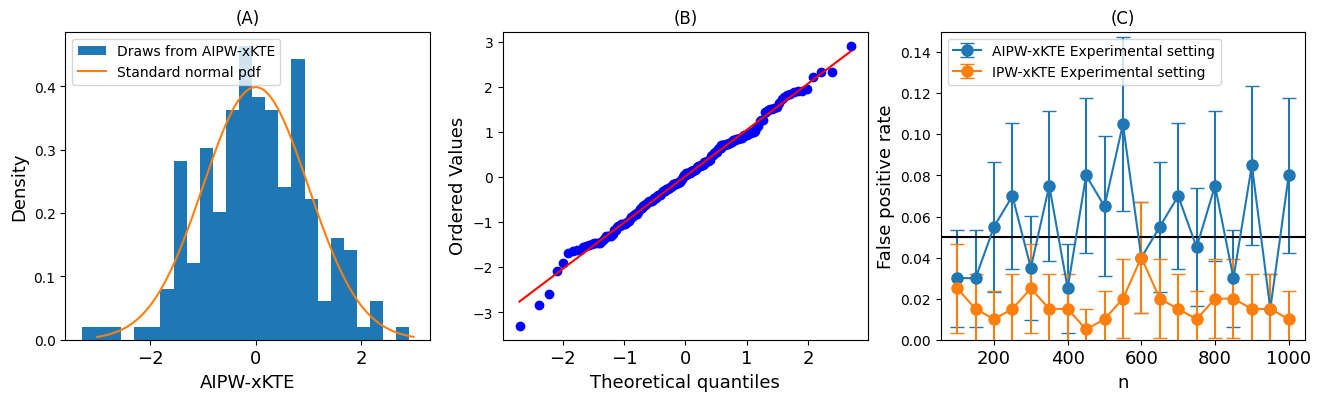

In [19]:
case = 1

plt.rcParams["figure.figsize"] = (16,4)
MEDIUM_SIZE=13
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE) 

b = 'I'
ns = 500
method = 'DR-xKTE'
experiment = True
name_folder = 'data' + str(experiment) + '/'
name = name_folder + 'ns' + str(ns) + 'b' + str(b) + 'case' + str(case) + method + '.csv'


plt.subplot(1, 3, 1)
bins = 25
x_axis = np.arange(-3, 3, 0.01)
stat_values = d[name]['stat_values']
plt.hist(stat_values, bins = bins, density=True, label="Draws from AIPW-xKTE")
plt.plot(x_axis, norm.pdf(x_axis, 0, 1), label='Standard normal pdf' )

plt.legend(loc="upper left")
plt.xlabel("AIPW-xKTE")
plt.ylabel("Density")
plt.title("(A)")
  

stats.probplot(stat_values, dist="norm", plot=plt.subplot(1, 3, 2))
plt.title("(B)")

m_dict = {0: "o", 1: "D", 2: "*", 3: "X", 4: "s"}
m_dict_title = {0: " Experimental setting", 1: " Observational setting"}
method_dict = {'DR-xKTE': 'AIPW-xKTE', 'IPW-xKTE': 'IPW-xKTE', 'KTE': 'KTE'}

plt.subplot(1, 3, 3)

confidence_level = 0.05
method_list = ['DR-xKTE', 'IPW-xKTE']
name_folder_list =  ['data' + 'True' + '/']
ns_list = np.arange(100, 1050, 50)
ns_array = np.array(ns_list)
rejection_proportion = np.zeros(len(ns_list))

for k, name_folder in enumerate(name_folder_list):
    for i, method in enumerate(method_list):
        for j, ns in enumerate(ns_list):
            name = name_folder + 'ns' + str(ns) + 'b' + str(b) + 'case' + str(case) + method + '.csv'
            rejection_proportion[j] = (d[name]['p_values'] < confidence_level).mean()
        varhat = rejection_proportion*(1 - rejection_proportion)/len(d[name]['p_values'])
        print(len(d[name]['p_values']))
        if i == 0:
            plt.errorbar(ns_array, rejection_proportion, yerr=1.96*np.sqrt(varhat), capsize=5, label=method_dict[method]+ m_dict_title[k], marker = m_dict[k], markersize=8, color = "C0")
        else:
            plt.errorbar(ns_array, rejection_proportion, yerr=1.96*np.sqrt(varhat), capsize=5, label=method_dict[method]+m_dict_title[k], marker = m_dict[k], markersize=8, color = "C1")
    
plt.title("(C)")
plt.xlabel("n")
plt.ylabel("False positive rate")
plt.axhline(confidence_level, c = "Black")
plt.ylim((0, confidence_level*3))
plt.legend(loc='upper left')
    
#plt.savefig("plots/null_dr.png", bbox_inches='tight')
plt.savefig("plots/REVIEWED_null_dr_experimental" + str(case) + "errorbar.png", bbox_inches='tight')

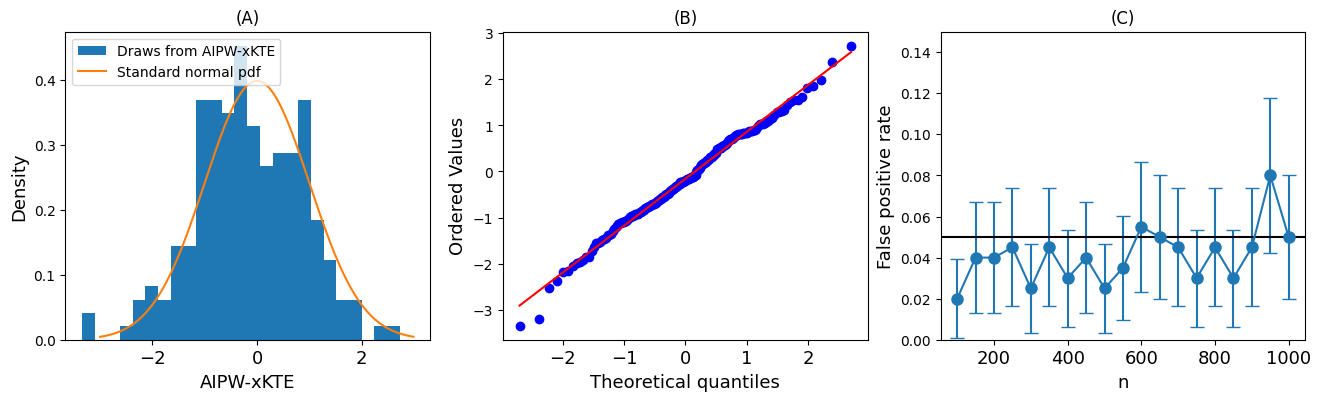

In [22]:
case = 1

plt.rcParams["figure.figsize"] = (16,4)
MEDIUM_SIZE=13
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE) 
b = 'I'
ns = 500
method = 'DR-xKTE'
experiment = False
name_folder = 'data' + str(experiment) + '/'

name = name_folder + 'ns' + str(ns) + 'b' + str(b) + 'case' + str(case) + method + '.csv'


plt.subplot(1, 3, 1)
bins = 25
x_axis = np.arange(-3, 3, 0.01)
stat_values = d[name]['stat_values']
plt.hist(stat_values, bins = bins, density=True, label="Draws from AIPW-xKTE")
plt.plot(x_axis, norm.pdf(x_axis, 0, 1), label='Standard normal pdf' )

plt.legend(loc="upper left")
plt.xlabel("AIPW-xKTE")
plt.ylabel("Density")
plt.title("(A)")
  

stats.probplot(stat_values, dist="norm", plot=plt.subplot(1, 3, 2))
plt.title("(B)")

m_dict = {0: "o", 1: "D", 2: "*", 3: "X", 4: "s"}
# m_dict_title = {0: "Observational setting", 1: " Observational setting"}
method_dict = {'DR-xKTENEW': 'AIPW-xKTE', 'IPW-xKTENEW': 'IPW-xKTE', 'KTE': 'KTE'}

plt.subplot(1, 3, 3)

confidence_level = 0.05
method_list = ['DR-xKTE']
name_folder_list =  ['data' + 'False' + '/']
ns_list = np.arange(100, 1050, 50)
ns_array = np.array(ns_list)
rejection_proportion = np.zeros(len(ns_list))

for k, name_folder in enumerate(name_folder_list):
    for i, method in enumerate(method_list):
        for j, ns in enumerate(ns_list):
            name = name_folder + 'ns' + str(ns) + 'b' + str(b) + 'case' + str(case) + method + '.csv'
            rejection_proportion[j] = (d[name]['p_values'] < confidence_level).mean()
        if i == 0:
            varhat = rejection_proportion*(1 - rejection_proportion)/len(d[name]['p_values'])
            plt.errorbar(x=ns_array, y=rejection_proportion, yerr=1.96*np.sqrt(varhat), capsize=5, marker = m_dict[k], markersize=8, color = "C0")
        
    
plt.title("(C)")
plt.xlabel("n")
plt.ylabel("False positive rate")
plt.axhline(confidence_level, c = "Black")
plt.ylim((0, confidence_level*3))
# plt.legend(loc='upper left')
    
#plt.savefig("plots/null_dr.png", bbox_inches='tight')
plt.savefig("plots/REVIEWED_null_dr_observational" + str(case) + "errorbar.png", bbox_inches='tight')

### Experimental and Observational setting

In [28]:
num_experiments = 100
iterations=100

ns_list = [100, 150, 200, 250, 300, 350]
b_list = ['II', 'III', 'IV']
method_list = ['DR-xKTE', 'IPW-xKTE', 'KTE']
case_list = [2]
experiment = True
name_folder = 'data' + str(experiment) + '/'

experiment_list = [False, True]
for experiment in experiment_list:
    name_folder = 'data' +str(experiment) + '/'
    run_tests(b_list, method_list, case_list, ns_list, experiment, name_folder, num_experiments, iterations)

b =  II
b =  III
b =  IV
b =  II
b =  III
b =  IV


In [31]:
# Scenarios II, III, IV experimental setting 
name_folder_list_true = ['data' + 'True' + '/']
ns_list_true = [100, 150, 200, 250, 300, 350]
ns_array_true = np.array(ns_list_true)
b_list_true = ['II', 'III', 'IV']
methods_true = ['DR-xKTE', 'IPW-xKTE', 'KTE']
case = 2
case_list_true = [case]

# Scenarios II, III, IV observational setting
name_folder_list_false = ['data' + 'False' + '/']
ns_list_false = [100, 150, 200, 250, 300, 350]
ns_array_false = np.array(ns_list_false)
b_list_false = ['II', 'III', 'IV']
methods_false = ['DR-xKTE', 'IPW-xKTE', 'KTE']
case = 2
case_list_false = [case]

for name_folder in name_folder_list_true:
    for b in b_list_true:
        for method in methods_true:
            for case in case_list_true:
                for ns in ns_array_true:
                    name = name_folder + 'ns' + str(ns) + 'b' + str(b) + 'case' + str(case) + method + '.csv'
                    d[name] = pd.read_csv(name, index_col = 0)

for name_folder in name_folder_list_false:
    for b in b_list_false:
        for method in methods_false:
            for case in case_list_false:
                for ns in ns_array_false:
                    name = name_folder + 'ns' + str(ns) + 'b' + str(b) + 'case' + str(case) + method + '.csv'
                    d[name] = pd.read_csv(name, index_col = 0)

### Observational setting

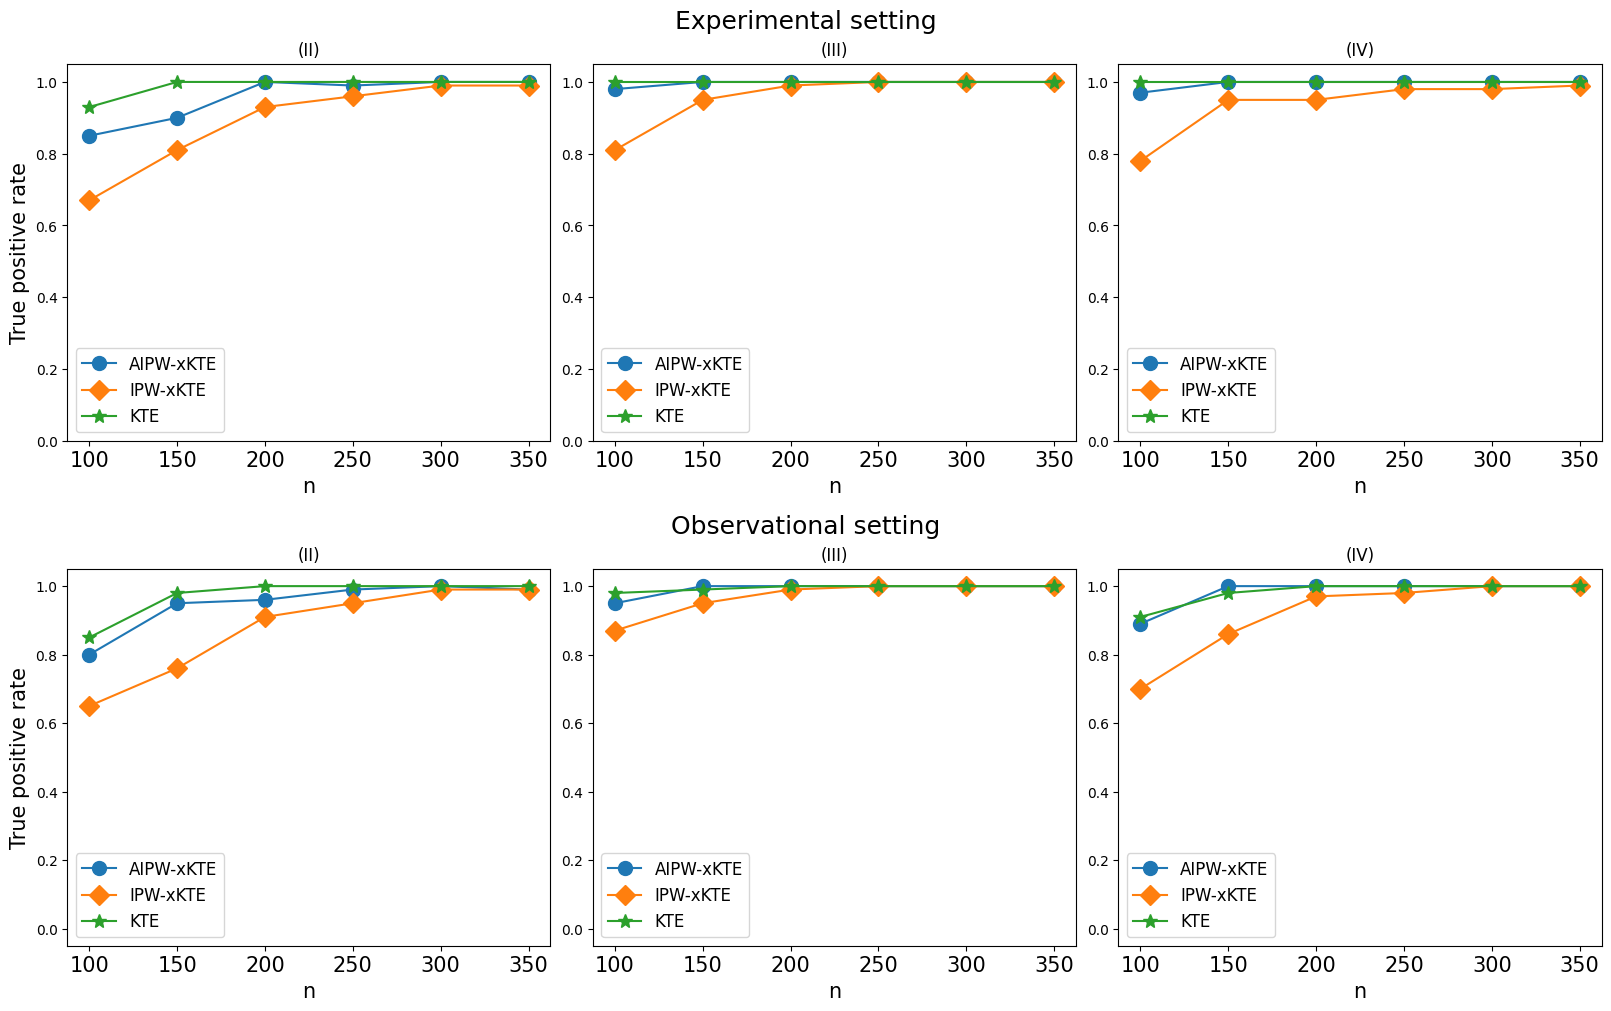

In [32]:
case = 2

ns_list = [100, 150, 200, 250, 300, 350]
ns_array = np.array(ns_list)

plt.rcParams["figure.figsize"] = (16,10)
plt.rc('legend',fontsize=12)
fig = plt.figure(constrained_layout=True)
MEDIUM_SIZE=15
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE) 
#plt.rcParams['axes.titlesize'] = 15

bs = ['II', 'III', 'IV']
bs_title = ['(II)', '(III)', '(IV)']
row_to_title = ['Experimental setting', 'Observational setting']
method_dict = {'DR-xKTE': 'AIPW-xKTE', 'IPW-xKTE': 'IPW-xKTE', 'KTE': 'KTE', 'BART': 'BART', 
               'CausalForest': 'CausalForest', 'Vanilla_DR': 'Baseline-AIPW', 'DR-xKTENEW': 'AIPW-xKTE', 'IPW-xKTENEW': 'IPW-xKTE'}
m_dict = {0: "o", 1: "D", 2: "*", 3: "X", 4: "s"}
    
# create 2x1 subfigs
subfigs = fig.subfigures(nrows=2, ncols=1)


row = 0 
subfig = subfigs[0] 
subfig.suptitle(row_to_title[row], fontsize = 18)
name_folder = 'data' + 'True' + '/'

# create 1x3 subplots per subfig
axs = subfig.subplots(nrows=1, ncols=3)
for col, ax in enumerate(axs):
    ax.plot()
    ax.set_title(bs_title[col])
    ax.set_ylim((0., 1.05))
    ax.set_xlabel("n")
    if col == 0:
        ax.set_ylabel("True positive rate")
    rejection_proportion = np.zeros((len(methods_true), len(ns_list)))
    b = bs[col]
    for i, method in enumerate(methods_true): 
        for j, ns in enumerate(ns_list):
            name = name_folder + 'ns' + str(ns) + 'b' + str(b) + 'case' + str(case) + method + '.csv'
            rejection_proportion[i, j] = (d[name]['p_values'] < confidence_level).mean()
        ax.plot(ns_array, rejection_proportion[i, :], label = method_dict[method], marker = m_dict[i], markersize=10)
    ax.legend(loc='lower left')
    
row = 1
subfig = subfigs[1] 
subfig.suptitle(row_to_title[row], fontsize = 18)
name_folder = 'data' + 'False' + '/'

# create 1x3 subplots per subfig
axs = subfig.subplots(nrows=1, ncols=3)
for col, ax in enumerate(axs):
    ax.plot()
    ax.set_title(bs_title[col])
    ax.set_ylim((-0.05, 1.05))
    ax.set_xlabel("n")
    if col == 0:
        ax.set_ylabel("True positive rate")
    rejection_proportion = np.zeros((len(methods_false), len(ns_list)))
    b = bs[col]
    for i, method in enumerate(methods_false): 
        for j, ns in enumerate(ns_list):
            name = name_folder + 'ns' + str(ns) + 'b' + str(b) + 'case' + str(case) + method + '.csv'
            rejection_proportion[i, j] = (d[name]['p_values'] < confidence_level).mean()
        ax.plot(ns_array, rejection_proportion[i, :], label = method_dict[method], marker = m_dict[i], markersize=10)
    ax.legend(loc='lower left')

#plt.savefig("plots/scenarios234" + str(case) + ".png", bbox_inches='tight')    
#fontweight = 'bold'
        